In [1]:
#import files
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

In [2]:
# dataset path
dataset_path = '../datasets/raw/dataset'

IMG_SIZE = 128 # Size to which images will be resized

images = []
labels = []

# loop through each folder in the dataset
for character in tqdm(os.listdir(dataset_path)):
    character_path = os.path.join(dataset_path, character)

    # check if the path is a directory
    if not os.path.isdir(character_path):
        continue
    
    # loop through each image in the folder
    for img_file in tqdm(os.listdir(character_path), desc=f"Preprocessing {character}"):
        try:
            img_path = os.path.join(character_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize image to IMG_SIZE x IMG_SIZE
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
            images.append(img)
            labels.append(character)  # Append the character label
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue #skip the image if there's an error

100%|██████████| 130/130 [01:23<00:00,  1.55it/s]


In [3]:
X = np.array(images, dtype=np.float32) / 255.0  # Normalize images to [0, 1]
y = np.array(labels)

# Encode labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded) # Convert labels to categorical format

# Train-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y_categorical, test_size=0.2, random_state=42) # Split into training and temporary set size 20%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42) # Split temporary set into validation and test sets, each 10% of the original dataset

# print dataset shapes
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")
print(f"Number of classes: {len(le.classes_)}")

Training set shape: (7789, 128, 128, 3), (7789, 130)
Validation set shape: (974, 128, 128, 3), (974, 130)
Test set shape: (974, 128, 128, 3), (974, 130)
Number of classes: 130


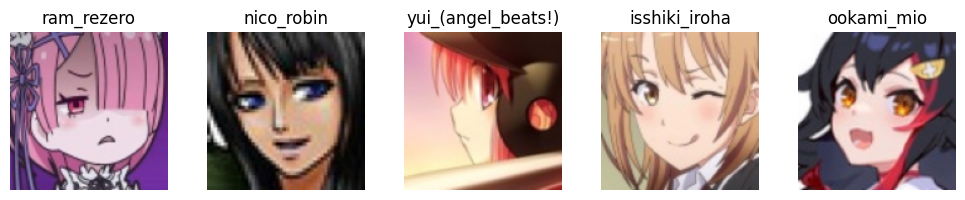

In [7]:
# visualize 5 random samples
plt.figure(figsize=(10, 2))
for i in range(5):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(le.inverse_transform([np.argmax(y_train[idx])])[0])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# Save the preprocessed data
np.savez_compressed('../datasets/processed/dataset.npz', 
                   X_train=X_train, y_train=y_train, 
                   X_val=X_val, y_val=y_val, 
                   X_test=X_test, y_test=y_test, 
                   classes=le.classes_)
print("Preprocessing complete. Data saved to '../datasets/processed/dataset.npz'.")
# End of the script
# Note: Ensure that the dataset path and save path are correct before running the script.

Preprocessing complete. Data saved to '../datasets/processed/dataset.npz'.
